# thalamus: spindle3 for 包含c2tsc和scale2的同时运行

In [1]:
# how to import python files in other directory
import os
import sys
os.chdir("../../")
now_dir = os.getcwd()
print(now_dir)

# the path appended to sys.path is an absolute path
sys.path.append(os.path.join(now_dir, r'models\util'))
sys.path.append(os.path.join(now_dir, r'models\spindle_3'))

d:\mynew\demo_all


In [2]:

import pypet as pp 
import numpy as np 

# utils libs
import runModels as rm 
import defaultParameters as dp
#params = dp.loadDefaultParams(0)
#params["scale2"] = 0.004
#params 

### 生成不同Jer/Jet/scale2的npy

In [3]:
import numpy as np
import runModels as rm
import defaultParameters as dp
import os
from itertools import product

# ========== 参数设置 ==========
n_runs = 15  # 每个参数组合运行次数
c2tsc = 1  # 固定 c2tsc

# 三参数扫描范围
scale2_list = np.linspace(0, 0.0002, 4)      # 0, 6.67e-5, 1.33e-4, 2e-4
Jet_list = np.linspace(0, 1.98 * 30, 15)      # 0, 19.8, 39.6, 59.4
Jer_list = np.linspace(0, 3.24 * 30, 6)      # 0, 32.4, 64.8, 97.2

print("="*60)
print("三参数扫描设置")
print("="*60)
print(f"scale2: {scale2_list}")
print(f"Jet: {Jet_list}")
print(f"Jer: {Jer_list}")
print(f"总参数组合: {len(scale2_list) * len(Jet_list) * len(Jer_list)}")
print(f"总运行次数 (含seed): {len(scale2_list) * len(Jet_list) * len(Jer_list) * n_runs}")

# ========== 创建保存目录 ==========
DATA_DIR = "data/raw_data_3param_scan"
os.makedirs(DATA_DIR, exist_ok=True)

# ========== 统计已完成文件（支持断点续跑）==========
existing_files = set()
for f in os.listdir(DATA_DIR):
    if f.endswith(".npy"):
        existing_files.add(f)
print(f"\n已存在 {len(existing_files)} 个文件")

# ========== 生成任务列表 ==========
tasks = []
for scale2_val in scale2_list:
    for Jet_val in Jet_list:
        for Jer_val in Jer_list:
            for seed in range(1, n_runs + 1):
                # 生成文件名
                filename = f"c2tsc_{c2tsc:.4f}_scale2_{scale2_val:.6f}_Jet_{Jet_val:.4f}_Jer_{Jer_val:.4f}_seed_{seed}.npy"
                if filename in existing_files:
                    continue
                tasks.append((scale2_val, Jet_val, Jer_val, seed, filename))

print(f"待运行任务数: {len(tasks)}")

if len(tasks) == 0:
    print("所有任务已完成！")
    exit()

# ========== 运行任务 ==========
total = len(tasks)
completed = 0

for scale2_val, Jet_val, Jer_val, seed, filename in tasks:
    save_path = os.path.join(DATA_DIR, filename)
    
    # 加载默认参数并修改
    params = dp.loadDefaultParams(seed)
    params["c2tsc"] = c2tsc
    params["scale2"] = scale2_val
    params["Jet"] = Jet_val
    params["Jer"] = Jer_val
    
    # 运行模型
    try:
        t, Q_t, Q_r, V_t, V_r, Q_e, Q_i, V_e, V_i, c, V_e2, V_i2, c2 = rm.runModels(manual_params=params)
    except Exception as e:
        print(f"失败: {filename}, 错误: {e}")
        continue
    
    # 保存 raw 信号
    np.save(save_path, {
        "t": t, "V_e": V_e, "V_i": V_i, 
        "Q_e": Q_e, "Q_i": Q_i, 
        "V_t": V_t, "V_r": V_r, 
        "Q_t": Q_t, "Q_r": Q_r,
        "c2tsc": c2tsc,
        "scale2": scale2_val,
        "Jet": Jet_val,
        "Jer": Jer_val,
        "seed": seed
    })
    
    completed += 1
    if completed % 10 == 0:
        print(f"进度: {completed}/{total}")

print(f"\n完成！共运行 {completed} 个任务")
print(f"数据保存在: {DATA_DIR}")

三参数扫描设置
scale2: [0.00000000e+00 6.66666667e-05 1.33333333e-04 2.00000000e-04]
Jet: [ 0.          4.24285714  8.48571429 12.72857143 16.97142857 21.21428571
 25.45714286 29.7        33.94285714 38.18571429 42.42857143 46.67142857
 50.91428571 55.15714286 59.4       ]
Jer: [ 0.   19.44 38.88 58.32 77.76 97.2 ]
总参数组合: 360
总运行次数 (含seed): 5400

已存在 0 个文件
待运行任务数: 5400
进度: 10/5400
进度: 20/5400
进度: 30/5400
进度: 40/5400
进度: 50/5400
进度: 60/5400
进度: 70/5400
进度: 80/5400
进度: 90/5400
进度: 100/5400
进度: 110/5400
进度: 120/5400
进度: 130/5400
进度: 140/5400
进度: 150/5400
进度: 160/5400
进度: 170/5400
进度: 180/5400
进度: 190/5400
进度: 200/5400
进度: 210/5400
进度: 220/5400
进度: 230/5400
进度: 240/5400
进度: 250/5400
进度: 260/5400
进度: 270/5400
进度: 280/5400
进度: 290/5400
进度: 300/5400
进度: 310/5400
进度: 320/5400
进度: 330/5400
进度: 340/5400
进度: 350/5400
进度: 360/5400
进度: 370/5400
进度: 380/5400
进度: 390/5400
进度: 400/5400
进度: 410/5400
进度: 420/5400
进度: 430/5400
进度: 440/5400
进度: 450/5400
进度: 460/5400
进度: 470/5400
进度: 480/5400
进度: 490/5400
进度: 500

In [4]:
import requests
ret = requests.get('https://api.day.app/TUiWwsBpShFTPWk8JWWLxW/program/thalamusfor20251128_11:10isdone')


#### 分析 Jet Jer scale2 的spindles 无mask

In [6]:
import numpy as np
import pandas as pd
import yasa
import glob
import os
import xarray as xr
from scipy.signal import hilbert
from neurolib.utils.signal import Signal, RatesSignal

# ========== 1. 参数设置 ==========
sf = 10000  # 采样率
remove_edges_samples = 20000  # 去掉前后各 2 秒
SW = {"low_freq": 0.5, "high_freq": 2.0}  # 慢波滤波范围

DATA_DIR = "data/raw_data_3param_scan"
OUTPUT_CSV = "data/analysis_data/spindles_3param_scan.csv"

# ========== 2. 函数定义 ==========
def get_phase_and_filtered(signal, filter_args, pad=None):
    """返回相位和滤波后的信号（使用 neurolib Signal）"""
    assert isinstance(signal, Signal)
    phase = signal.detrend(inplace=False)
    if pad:
        phase.pad(how_much=pad, in_seconds=True, padding_type="reflect", side="both")
    phase.filter(**filter_args)
    filtered = phase.data.values.copy()
    phase.hilbert_transform(return_as="phase_wrapped")
    if pad:
        phase.sel([phase.start_time + pad, phase.end_time - pad])
    return phase.data.values, filtered

def process_spindles(sp, spindle_type, params, t_mid, sf, t_min, t_max, slow_phase):
    """处理纺锤波检测结果，返回列表"""
    results = []
    if sp is None:
        return results
    
    df = sp.summary()
    for _, row in df.iterrows():
        start_time = row["Start"]
        peak_time = row["Peak"]
        end_time = row["End"]
        
        start_idx_sample = int(start_time * sf)
        peak_idx_sample = int(peak_time * sf)
        end_idx_sample = int(end_time * sf)
        
        if not (t_min <= start_idx_sample <= t_max and t_min <= end_idx_sample <= t_max):
            continue
        
        start_idx = np.argmin(np.abs(t_mid - start_idx_sample))
        peak_idx = np.argmin(np.abs(t_mid - peak_idx_sample))
        end_idx = np.argmin(np.abs(t_mid - end_idx_sample))
        
        results.append({
            **params,
            "type": spindle_type,
            "start": start_time,
            "peak_time": peak_time,
            "end": end_time,
            "duration": row["Duration"],
            "frequency": row["Frequency"],
            "amplitude": row["Amplitude"],
            "phase_at_start": slow_phase[start_idx],
            "phase_at_peak": slow_phase[peak_idx],
            "phase_at_end": slow_phase[end_idx],
        })
    return results

# ========== 3. 读取所有文件 ==========
file_list = glob.glob(os.path.join(DATA_DIR, "*.npy"))
print(f"找到 {len(file_list)} 个文件")

# ========== 4. 批量处理 ==========
all_spindles = []

for file_path in file_list:
    file_path = file_path.replace("\\", "/")
    filename = os.path.basename(file_path)
    parts = filename.replace(".npy", "").split("_")
    
    # 解析文件名
    c2tsc = float(parts[1])
    scale2 = float(parts[3])
    Jet = float(parts[5])
    Jer = float(parts[7])
    seed = int(parts[9])
    
    print(f"Processing: c2tsc={c2tsc:.4f}, scale2={scale2:.6f}, Jet={Jet:.4f}, Jer={Jer:.4f}, seed={seed}")
    
    # 加载数据
    data = np.load(file_path, allow_pickle=True).item()
    t = data["t"]
    V_t = data["V_t"]
    V_e = data["V_e"]
    
    # 计算时间边界
    t_min = remove_edges_samples
    t_max = t[-1] - remove_edges_samples
    
    # 只保留中间部分用于相位计算
    mask = (t >= t_min) & (t <= t_max)
    t_mid = t[mask]
    V_e_mid = V_e[mask]
    
    if len(t_mid) == 0:
        print(f"  警告：没有有效数据，跳过")
        continue
    
    # 构建 neurolib Signal 对象
    results_df = pd.DataFrame({"ALN": V_e_mid}, index=t_mid / sf)
    results_df.index.name = "time"
    aln_xr = xr.DataArray(results_df["ALN"])
    aln_sig = RatesSignal(aln_xr)
    
    # 计算慢波相位
    slow_phase, V_slow = get_phase_and_filtered(aln_sig, filter_args=SW, pad=0.0)
    
    params = {
        "c2tsc": c2tsc,
        "scale2": scale2,
        "Jet": Jet,
        "Jer": Jer,
        "seed": seed,
    }
    
    # 检测快纺锤波（12-16 Hz）
    sp_fast = yasa.spindles_detect(V_t, sf, freq_sp=(12, 16), duration=(0.3, 2))
    all_spindles.extend(process_spindles(sp_fast, "fast", params, t_mid, sf, t_min, t_max, slow_phase))
    
    # 检测慢纺锤波（8-12 Hz）
    sp_slow = yasa.spindles_detect(V_t, sf, freq_sp=(8, 12), duration=(0.3, 2))
    all_spindles.extend(process_spindles(sp_slow, "slow", params, t_mid, sf, t_min, t_max, slow_phase))
    
    print(f"  完成：快={len(sp_fast.summary()) if sp_fast else 0}, 慢={len(sp_slow.summary()) if sp_slow else 0}")

# ========== 5. 保存结果 ==========
os.makedirs(os.path.dirname(OUTPUT_CSV), exist_ok=True)
result_df = pd.DataFrame(all_spindles)
result_df.to_csv(OUTPUT_CSV, index=False)

print(f"\n总共检测到 {len(result_df)} 个纺锤波")
print(f"快纺锤波: {len(result_df[result_df['type'] == 'fast'])}")
print(f"慢纺锤波: {len(result_df[result_df['type'] == 'slow'])}")
print(f"CSV 已保存: {OUTPUT_CSV}")

# ========== 6. 打印参数范围 ==========
print("\n参数范围:")
print(f"  c2tsc: {result_df['c2tsc'].min():.4f} ~ {result_df['c2tsc'].max():.4f}")
print(f"  scale2: {result_df['scale2'].min():.6f} ~ {result_df['scale2'].max():.6f}")
print(f"  Jet: {result_df['Jet'].min():.4f} ~ {result_df['Jet'].max():.4f}")
print(f"  Jer: {result_df['Jer'].min():.4f} ~ {result_df['Jer'].max():.4f}")

print("\n前几行:")
print(result_df.head())

找到 5400 个文件
Processing: c2tsc=1.0000, scale2=0.000000, Jet=0.0000, Jer=0.0000, seed=1
Setting up band-pass filter from 0.5 - 2 Hz


d:\anaconda\envs\neurolib_old\lib\site-packages\outdated\utils.py:18: OutdatedPackageWarning: The package yasa is out of date. Your version is 0.6.3, the latest is 0.7.0.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  **kwargs



FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 2.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 3.00 Hz)
- Filter length: 66001 samples (6.600 sec)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent work

  完成：快=1, 慢=2
Processing: c2tsc=1.0000, scale2=0.000000, Jet=0.0000, Jer=0.0000, seed=10
Setting up band-pass filter from 0.5 - 2 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 2.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 3.00 Hz)
- Filter length: 66001 samples (6.600 sec)



...

  完成：快=6, 慢=8
Processing: c2tsc=1.0000, scale2=0.000200, Jet=8.4857, Jer=97.2000, seed=8
Setting up band-pass filter from 0.5 - 2 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 2.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 3.00 Hz)
- Filter length: 66001 samples (6.600 sec)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent work

  完成：快=8, 慢=6
Processing: c2tsc=1.0000, scale2=0.000200, Jet=8.4857, Jer=97.2000, seed=9
Setting up band-pass filter from 0.5 - 2 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 2.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 3.00 Hz)
- Filter length: 66001 samples (6.600 sec)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent work

  完成：快=10, 慢=6

总共检测到 66183 个纺锤波
快纺锤波: 32891
慢纺锤波: 33292
CSV 已保存: data/analysis_data/spindles_3param_scan.csv

参数范围:
  c2tsc: 1.0000 ~ 1.0000
  scale2: 0.000000 ~ 0.000200
  Jet: 0.0000 ~ 59.4000
  Jer: 0.0000 ~ 97.2000

前几行:
   c2tsc  scale2  Jet  Jer  seed  type    start  peak_time      end  duration  \
0    1.0     0.0  0.0  0.0     1  slow   2.5694     2.9041   3.3362    0.7668   
1    1.0     0.0  0.0  0.0    10  fast   3.5726     3.8795   3.9726    0.4000   
2    1.0     0.0  0.0  0.0    10  fast   6.3124     6.5810   6.7216    0.4092   
3    1.0     0.0  0.0  0.0    10  fast   7.8078     8.0234   8.2422    0.4344   
4    1.0     0.0  0.0  0.0    10  fast  11.2257    11.3082  11.6434    0.4177   

   frequency  amplitude  phase_at_start  phase_at_peak  phase_at_end  
0  10.366004   3.823330       -0.075685       1.410798      3.133872  
1  12.168361   3.498695       -2.682770      -2.089461     -1.906214  
2  12.453906   4.719413       -2.107384      -1.633580     -1.407817  
3  

In [5]:
agsldgah

NameError: name 'agsldgah' is not defined

In [ ]:
import numpy as np
import runModels as rm
import defaultParameters as dp
import os

# ========== 参数设置 ==========
#n_runs = 1
n_runs = 20
#c2tsc_list = [0.8]      # 2 个 c2tsc 值
c2tsc_list = np.linspace(0, 1, 21)      # 20 个 c2tsc 值
#scale2_list = [0.0013]  # 2   个 scale2 值
scale2_list = np.linspace(0, 0.003, 13)  # 10 个 scale2 值
print(c2tsc_list)
print(scale2_list)

# 创建保存目录
os.makedirs("data/raw_data_nonoise", exist_ok=True)

for c2tsc in c2tsc_list:
    for scale2 in scale2_list:
        for seed in range(1, n_runs + 1):  # 1 到 10
            # 加载默认参数并修改
            params = dp.loadDefaultParams(seed)
            params["c2tsc"] = c2tsc
            params["scale2"] = 0.0013

            
            # 运行模型
            t, Q_t, Q_r, V_t, V_r, Q_e, Q_i, V_e, V_i, c, V_e2, V_i2, c2 = rm.runModels(manual_params=params)
            
            # 保存 raw 信号，文件名包含 c2tsc 和 scale2
            #save_path = f"data/raw_data_explore/c2tsc_{c2tsc:.4f}_scale2_{scale2:.4f}_tause_{tau_se:.4f}_seed_{seed}.npy"
            save_path = f"data/raw_data_nonoise/c2tsc_{c2tsc:.4f}_scale2_{scale2:.4f}_seed_{seed}.npy"
            np.save(save_path, {
                "t": t, "V_e": V_e, "V_i": V_i, 
                "Q_e": Q_e, "Q_i": Q_i, 
                "V_t": V_t, "V_r": V_r, 
                "Q_t": Q_t, "Q_r": Q_r,
                "c2tsc": c2tsc,
                "scale2": scale2,
                "seed": seed
            })
            print(f"Saved: c2tsc={c2tsc:.4f}, scale2={scale2:.4f}, tau_se={tau_se:.4f}, seed={seed}")
            #print(f"Saved: c2tsc={c2tsc:.4f}, scale2={scale2:.4f}, seed={seed}")

[0.8]
[0.0013]
Saved: c2tsc=0.8000, scale2=0.0013, tau_se=2.0000, seed=1
Saved: c2tsc=0.8000, scale2=0.0013, tau_se=2.0000, seed=2
Saved: c2tsc=0.8000, scale2=0.0013, tau_se=2.0000, seed=3
Saved: c2tsc=0.8000, scale2=0.0013, tau_se=2.0000, seed=4
Saved: c2tsc=0.8000, scale2=0.0013, tau_se=2.0000, seed=5
Saved: c2tsc=0.8000, scale2=0.0013, tau_se=2.0000, seed=6
Saved: c2tsc=0.8000, scale2=0.0013, tau_se=2.0000, seed=7
Saved: c2tsc=0.8000, scale2=0.0013, tau_se=2.0000, seed=8
Saved: c2tsc=0.8000, scale2=0.0013, tau_se=2.0000, seed=9
Saved: c2tsc=0.8000, scale2=0.0013, tau_se=2.0000, seed=10
Saved: c2tsc=0.8000, scale2=0.0013, tau_se=2.0000, seed=11
Saved: c2tsc=0.8000, scale2=0.0013, tau_se=2.0000, seed=12
Saved: c2tsc=0.8000, scale2=0.0013, tau_se=2.0000, seed=13
Saved: c2tsc=0.8000, scale2=0.0013, tau_se=2.0000, seed=14
Saved: c2tsc=0.8000, scale2=0.0013, tau_se=2.0000, seed=15
Saved: c2tsc=0.8000, scale2=0.0013, tau_se=2.0000, seed=16
Saved: c2tsc=0.8000, scale2=0.0013, tau_se=2.0000,

In [ ]:
import requests
ret = requests.get('https://api.day.app/TUiWwsBpShFTPWk8JWWLxW/program/thalamusfor20251128_11:10isdone')


#### 分析不同参数对耦合相位的影响

读取 66183 个纺锤波
有效相位纺锤波: 66183
过滤 c2tsc=1 后: 66183

Jet 值数量: 15
Jer 值数量: 6
scale2 值数量: 4

分析 Jet (固定 scale2 和 Jer)

Jet: 有效的 (scale2, Jer) 组合数: 24


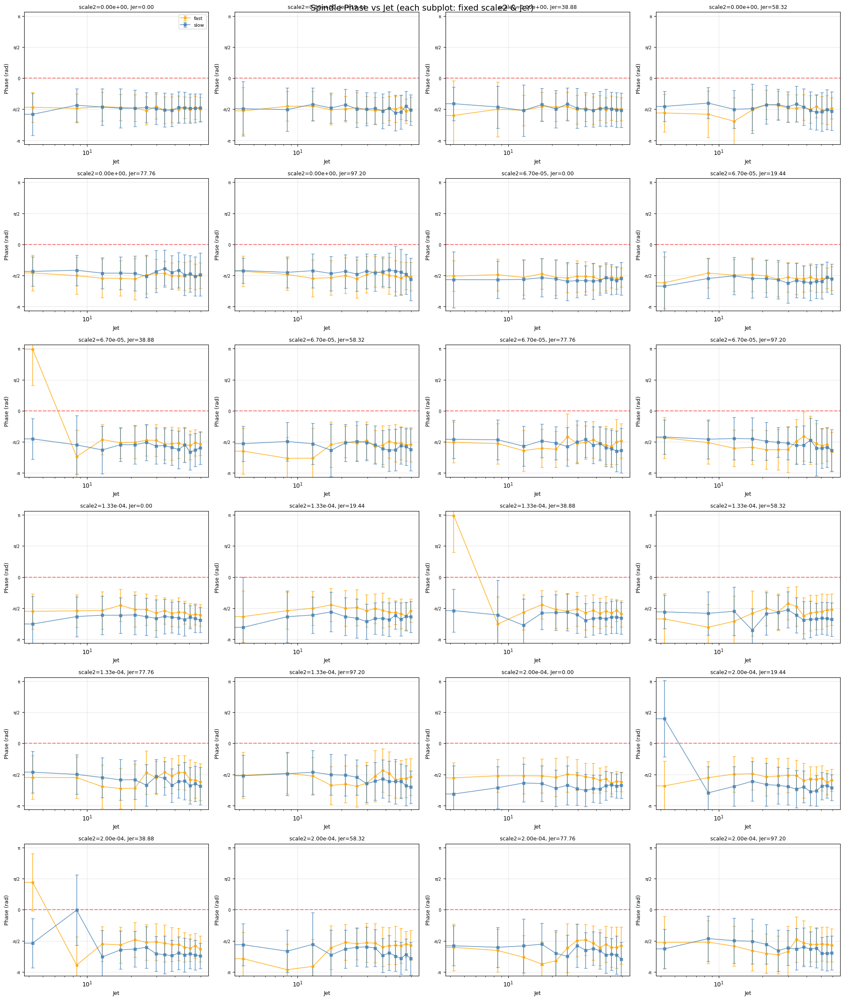


分析 Jer (固定 scale2 和 Jet)

Jer: 有效的 (scale2, Jet) 组合数: 60


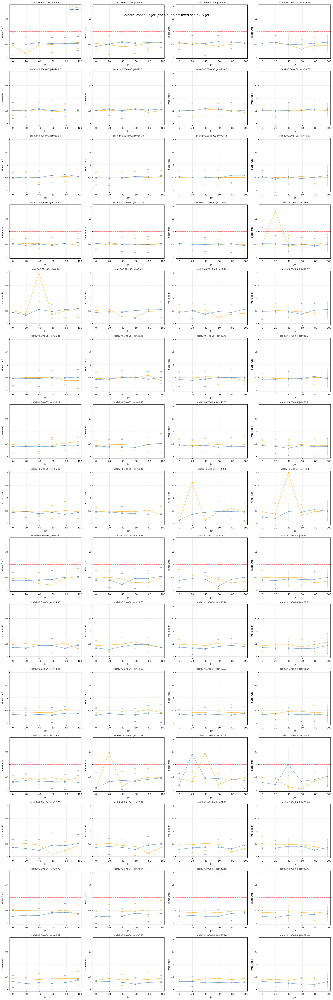


分析 scale2 (固定 Jet 和 Jer)

scale2: 有效的 (Jet, Jer) 组合数: 90


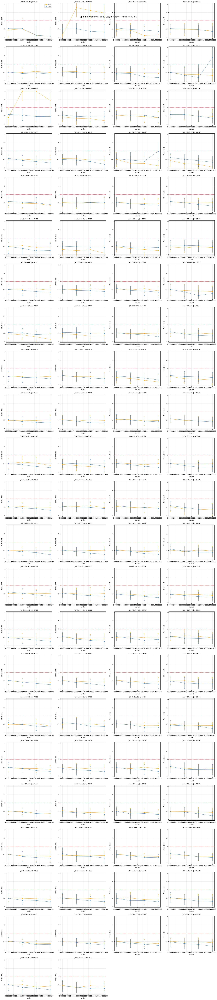


统计摘要（phase_at_end）

--- Jet (fixed scale2 & Jer) ---

  scale2=0.00e+00, Jer=0.00:
    Jet=0.00: Fast n=96, mean=-1.75±1.49 Slow n=100, mean=-1.51±1.43
    Jet=4.24: Fast n=91, mean=-1.47±0.76 Slow n=93, mean=-1.83±1.06
    Jet=8.49: Fast n=90, mean=-1.52±0.74 Slow n=96, mean=-1.37±0.84

--- Jer (fixed scale2 & Jet) ---

  scale2=0.00e+00, Jet=0.00:
    Jer=0.00: Fast n=96, mean=-1.75±1.49 Slow n=100, mean=-1.51±1.43
    Jer=19.44: Fast n=104, mean=-2.70±2.00 Slow n=90, mean=-1.56±0.98
    Jer=38.88: Fast n=103, mean=-1.68±1.24 Slow n=102, mean=-1.39±0.75

--- scale2 (fixed Jet & Jer) ---

  Jet=0.00e+00, Jer=0.00:
    scale2=0.00: Fast n=96, mean=-1.75±1.49 Slow n=100, mean=-1.51±1.43
    scale2=0.00: Fast n=96, mean=-1.57±1.99 Slow n=100, mean=-1.51±2.02
    scale2=0.00: Fast n=96, mean=-2.77±1.63 Slow n=100, mean=-2.77±2.80


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import circmean, circstd

# ========== 1. 读取数据 ==========
CSV_PATH = "data/analysis_data/spindles_3param_scan.csv"
df = pd.read_csv(CSV_PATH)
print(f"读取 {len(df)} 个纺锤波")

# ========== 2. 筛选有效相位 ==========
df_valid = df[df['phase_at_end'].notna()].copy()
print(f"有效相位纺锤波: {len(df_valid)}")

# 过滤 c2tsc=1
df_valid = df_valid[df_valid['c2tsc'] == 1.0].copy()
print(f"过滤 c2tsc=1 后: {len(df_valid)}")

# ========== 3. 定义圆形统计函数 ==========
def circular_stats(phases):
    if len(phases) == 0:
        return np.nan, np.nan, 0
    mean_p = circmean(phases, low=-np.pi, high=np.pi)
    std_p = circstd(phases, low=-np.pi, high=np.pi)
    return mean_p, std_p, len(phases)

# ========== 4. 获取所有参数值 ==========
Jet_values = sorted(df_valid['Jet'].unique())
Jer_values = sorted(df_valid['Jer'].unique())
scale2_values = sorted(df_valid['scale2'].unique())

print(f"\nJet 值数量: {len(Jet_values)}")
print(f"Jer 值数量: {len(Jer_values)}")
print(f"scale2 值数量: {len(scale2_values)}")

# ========== 5. 绘图函数 ==========
def plot_param_vs_phase(param_name, fixed_param1, fixed_param2, df_valid):
    """
    param_name: 要分析的参数 ('Jet', 'Jer', 'scale2')
    fixed_param1, fixed_param2: 要固定的两个参数名
    """
    # 获取固定参数的所有值
    values1 = sorted(df_valid[fixed_param1].unique())
    values2 = sorted(df_valid[fixed_param2].unique())
    
    # 生成所有有效组合
    valid_combinations = []
    for v1 in values1:
        for v2 in values2:
            subset = df_valid[(np.abs(df_valid[fixed_param1] - v1) < 1e-6) & 
                              (np.abs(df_valid[fixed_param2] - v2) < 1e-6)]
            if len(subset) > 0:
                valid_combinations.append((v1, v2))
    
    print(f"\n{param_name}: 有效的 ({fixed_param1}, {fixed_param2}) 组合数: {len(valid_combinations)}")
    
    if len(valid_combinations) == 0:
        print(f"  没有有效组合，跳过")
        return
    
    # 计算子图布局
    n_combos = len(valid_combinations)
    n_cols = min(4, n_combos)
    n_rows = (n_combos + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    if n_rows == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows == 1 or n_cols == 1:
        axes = axes.flatten()
    
    colors_type = {'fast': 'orange', 'slow': 'steelblue'}
    markers = {'fast': 'o', 'slow': 's'}
    
    for idx, (v1_val, v2_val) in enumerate(valid_combinations):
        row = idx // n_cols
        col = idx % n_cols
        
        if n_rows == 1 and n_cols == 1:
            ax = axes[0, 0]
        elif n_rows == 1 or n_cols == 1:
            ax = axes[idx]
        else:
            ax = axes[row, col]
        
        # 筛选：固定两个参数
        subset = df_valid[(np.abs(df_valid[fixed_param1] - v1_val) < 1e-6) & 
                          (np.abs(df_valid[fixed_param2] - v2_val) < 1e-6)]
        
        for spindle_type in ['fast', 'slow']:
            means = []
            stds = []
            vals = []
            
            for p_val in sorted(subset[param_name].unique()):
                sub = subset[(subset[param_name] == p_val) & (subset['type'] == spindle_type)]
                phases = sub['phase_at_end'].dropna().values
                if len(phases) > 0:
                    m, s, n = circular_stats(phases)
                    means.append(m)
                    stds.append(s)
                    vals.append(p_val)
            
            vals = np.array(vals)
            means = np.array(means)
            stds = np.array(stds)
            valid = ~np.isnan(means)
            
            if np.any(valid):
                ax.errorbar(vals[valid], means[valid], yerr=stds[valid],
                            fmt=f'{markers[spindle_type]}-', color=colors_type[spindle_type],
                            capsize=3, label=spindle_type, alpha=0.8, markersize=4, linewidth=1.2)
        
        ax.set_xlabel(param_name, fontsize=9)
        ax.set_ylabel('Phase (rad)', fontsize=9)
        ax.set_title(f'{fixed_param1}={v1_val:.2e}, {fixed_param2}={v2_val:.2f}', fontsize=9)
        ax.set_ylim(-np.pi - 0.2, np.pi + 0.2)
        ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
        ax.set_yticklabels(['-π', '-π/2', '0', 'π/2', 'π'], fontsize=7)
        ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
        ax.grid(True, alpha=0.3)
        if idx == 0:
            ax.legend(loc='upper right', fontsize=8)
        
        # 如果参数值跨度大，使用对数坐标
        if len(vals) > 0 and np.max(vals) / (np.min(vals[vals > 0]) + 1e-10) > 10:
            ax.set_xscale('log')
    
    # 隐藏多余的子图
    for idx in range(len(valid_combinations), n_rows * n_cols):
        row = idx // n_cols
        col = idx % n_cols
        if n_rows == 1 and n_cols == 1:
            axes[0, 0].axis('off')
        elif n_rows == 1 or n_cols == 1:
            axes[idx].axis('off')
        else:
            axes[row, col].axis('off')
    
    plt.suptitle(f'Spindle Phase vs {param_name} (each subplot: fixed {fixed_param1} & {fixed_param2})', fontsize=14)
    plt.tight_layout()
    plt.show()
    return fig

# ========== 6. 分别分析三个参数 ==========

# 6.1 分析 Jet（固定 scale2 和 Jer）
print("\n" + "="*60)
print("分析 Jet (固定 scale2 和 Jer)")
print("="*60)
plot_param_vs_phase('Jet', 'scale2', 'Jer', df_valid)

# 6.2 分析 Jer（固定 scale2 和 Jet）
print("\n" + "="*60)
print("分析 Jer (固定 scale2 和 Jet)")
print("="*60)
plot_param_vs_phase('Jer', 'scale2', 'Jet', df_valid)

# 6.3 分析 scale2（固定 Jet 和 Jer）
print("\n" + "="*60)
print("分析 scale2 (固定 Jet 和 Jer)")
print("="*60)
plot_param_vs_phase('scale2', 'Jet', 'Jer', df_valid)

# ========== 7. 打印统计摘要 ==========
print("\n" + "="*60)
print("统计摘要（phase_at_end）")
print("="*60)

for param_name, fixed_p1, fixed_p2 in [('Jet', 'scale2', 'Jer'), 
                                        ('Jer', 'scale2', 'Jet'), 
                                        ('scale2', 'Jet', 'Jer')]:
    print(f"\n--- {param_name} (fixed {fixed_p1} & {fixed_p2}) ---")
    
    # 取第一组固定值做示例
    p1_values = sorted(df_valid[fixed_p1].unique())
    p2_values = sorted(df_valid[fixed_p2].unique())
    
    found = False
    for v1 in p1_values[:2]:
        for v2 in p2_values[:2]:
            subset = df_valid[(np.abs(df_valid[fixed_p1] - v1) < 1e-6) & 
                              (np.abs(df_valid[fixed_p2] - v2) < 1e-6)]
            if len(subset) > 0:
                print(f"\n  {fixed_p1}={v1:.2e}, {fixed_p2}={v2:.2f}:")
                for p_val in sorted(subset[param_name].unique())[:3]:
                    sub = subset[(subset[param_name] == p_val) & (subset['type'] == 'fast')]
                    fast_phases = sub['phase_at_end'].dropna().values
                    sub = subset[(subset[param_name] == p_val) & (subset['type'] == 'slow')]
                    slow_phases = sub['phase_at_end'].dropna().values
                    
                    line = f"    {param_name}={p_val:.2f}:"
                    if len(fast_phases) > 0:
                        m, s, n = circular_stats(fast_phases)
                        line += f" Fast n={n}, mean={m:.2f}±{s:.2f}"
                    if len(slow_phases) > 0:
                        m, s, n = circular_stats(slow_phases)
                        line += f" Slow n={n}, mean={m:.2f}±{s:.2f}"
                    print(line)
                found = True
                break
        if found:
            break

### spindles for tau_se explore

In [ ]:
import numpy as np
import pandas as pd
import yasa
import glob
from scipy.signal import hilbert
import xarray as xr
from neurolib.utils.signal import Signal, RatesSignal
import os

# ========== 参数设置 ==========
sf = 10000  # 采样率
remove_edges_samples = 20000  # 去掉前后各 20000 个采样点（2秒）

# 慢波滤波参数
SW = {"low_freq": None, "high_freq": 3.0}

# 振幅阈值参数（用于掩码噪声片段）
amplitude_threshold = 2  # mV，只保留包络大于此值的片段

# ========== 限定 tau_se 范围 ==========
tau_se_min = 2
tau_se_max = 3

def get_phase_and_envelope(signal, filter_args, pad=None):
    """返回相位、滤波后的信号和包络（用于振幅掩码）"""
    assert isinstance(signal, Signal)
    phase = signal.detrend(inplace=False)
    if pad:
        phase.pad(
            how_much=pad, in_seconds=True, padding_type="reflect", side="both"
        )
    phase.filter(**filter_args)
    filtered = phase.data.values.copy()
    phase.hilbert_transform(return_as="phase_wrapped")
    if pad:
        phase.sel([phase.start_time + pad, phase.end_time - pad])
    
    # 计算包络（瞬时振幅）
    analytic = hilbert(filtered)
    envelope = np.abs(analytic)
    
    return phase.data.values, filtered, envelope

# ========== 批量处理 ==========
all_spindles = []
file_list = glob.glob("data/raw_data_explore/*.npy")
print(f"找到 {len(file_list)} 个文件")
print(f"限定 tau_se 范围: [{tau_se_min}, {tau_se_max}]")

for file_path in file_list:
    # 解析文件名，提取参数
    file_path = file_path.replace("\\", "/")
    filename = file_path.split("/")[-1]
    parts = filename.replace(".npy", "").split("_")
    
    # 根据文件名格式解析: c2tsc_{val}_scale2_{val}_tause_{val}_seed_{val}
    c2tsc = float(parts[1])
    scale2 = float(parts[3])
    tau_se = float(parts[5])
    seed = int(parts[7])
    
    # 只处理 tau_se 在指定范围内的文件
    if not (tau_se_min <= tau_se <= tau_se_max):
        continue
    
    print(f"Processing: c2tsc={c2tsc:.4f}, scale2={scale2:.4f}, tau_se={tau_se:.4f}, seed={seed}")
    
    # 加载数据
    data = np.load(file_path, allow_pickle=True).item()
    t = data["t"]
    V_t = data["V_t"]
    V_e = data["V_e"]
    
    # 计算时间边界（采样点）
    t_min = remove_edges_samples
    t_max = t[-1] - remove_edges_samples
    
    # 只保留中间部分用于相位计算
    mask = (t >= t_min) & (t <= t_max)
    t_mid = t[mask]
    V_t_mid = V_t[mask]
    V_e_mid = V_e[mask]
    
    if len(t_mid) == 0:
        print(f"  警告：没有有效数据，跳过")
        continue
    
    # 构建 neurolib Signal 对象
    results_df = pd.DataFrame(
        {"ALN": V_e_mid, "TCR": V_t_mid},
        index=t_mid / sf,
    )
    results_df.index.name = "time"
    
    aln_xr = xr.DataArray(results_df["ALN"])
    aln_sig = RatesSignal(aln_xr)
    
    # 计算慢波相位、滤波信号和包络
    slow_phase, V_slow, envelope = get_phase_and_envelope(aln_sig, filter_args=SW, pad=0.0)
    
    # ========== 振幅掩码：将小振幅片段的相位设为 NaN ==========
    mask_amplitude = envelope > amplitude_threshold
    slow_phase_masked = slow_phase.copy()
    slow_phase_masked[~mask_amplitude] = np.nan
    
    masked_ratio = np.sum(~mask_amplitude) / len(mask_amplitude) * 100
    print(f"  振幅掩码: 保留 {mask_amplitude.sum()}/{len(mask_amplitude)} 点 ({100-masked_ratio:.1f}%)")
    
    # ========== 处理纺锤波的通用函数 ==========
    def process_spindles(sp, spindle_type):
        """处理纺锤波检测结果，返回列表"""
        results = []
        if sp is None:
            return results
        
        df = sp.summary()
        for _, row in df.iterrows():
            start_time = row["Start"]
            peak_time = row["Peak"]
            end_time = row["End"]
            
            # 转换为采样点索引
            start_idx_sample = int(start_time * sf)
            peak_idx_sample = int(peak_time * sf)
            end_idx_sample = int(end_time * sf)
            
            # 检查纺锤波是否完全在有效窗口内
            if not (t_min <= start_idx_sample <= t_max and 
                    t_min <= end_idx_sample <= t_max):
                continue
            
            # 找到在中间信号中的索引
            start_idx = np.argmin(np.abs(t_mid - start_idx_sample))
            peak_idx = np.argmin(np.abs(t_mid - peak_idx_sample))
            end_idx = np.argmin(np.abs(t_mid - end_idx_sample))
            
            # 获取相位（使用掩码后的相位，小振幅处为 NaN）
            phase_start = slow_phase_masked[start_idx]
            phase_peak = slow_phase_masked[peak_idx]
            phase_end = slow_phase_masked[end_idx]
            
            results.append({
                "c2tsc": c2tsc,
                "scale2": scale2,
                "tau_se": tau_se,
                "seed": seed,
                "type": spindle_type,
                "start": start_time,
                "peak_time": peak_time,
                "end": end_time,
                "duration": row["Duration"],
                "frequency": row["Frequency"],
                "amplitude": row["Amplitude"],
                "phase_at_start": phase_start,
                "phase_at_peak": phase_peak,
                "phase_at_end": phase_end,
                "envelope_at_start": envelope[start_idx],
                "envelope_at_peak": envelope[peak_idx],
                "envelope_at_end": envelope[end_idx],
                "masked": np.isnan(phase_peak),
            })
        return results
    
    # 检测快纺锤波（12-16 Hz）
    sp_fast = yasa.spindles_detect(V_t, sf, freq_sp=(12,16), duration=(0.3,2))
    all_spindles.extend(process_spindles(sp_fast, "fast"))
    
    # 检测慢纺锤波（8-12 Hz）
    sp_slow = yasa.spindles_detect(V_t, sf, freq_sp=(8,12), duration=(0.3,2))
    all_spindles.extend(process_spindles(sp_slow, "slow"))
    
    print(f"  完成：快={len(sp_fast.summary()) if sp_fast else 0}, 慢={len(sp_slow.summary()) if sp_slow else 0}")

# ========== 保存结果 ==========
os.makedirs("data/analysis_data", exist_ok=True)
result_df = pd.DataFrame(all_spindles)
result_df.to_csv("data/analysis_data/spindles_tau_se_explore_limited.csv", index=False)

print(f"\n总共检测到 {len(result_df)} 个纺锤波")
print(f"其中相位被掩码的: {(result_df['masked'].sum())} / {len(result_df)}")

# 只保留相位有效的行
result_df_valid = result_df[~result_df['masked']].copy()
result_df_valid.to_csv("data/analysis_data/spindles_tau_se_explore_valid_limited.csv", index=False)
print(f"相位有效（未被掩码）的纺锤波: {len(result_df_valid)} 个")

print("\n参数范围:")
print(f"  c2tsc: {result_df['c2tsc'].min():.4f} ~ {result_df['c2tsc'].max():.4f}")
print(f"  scale2: {result_df['scale2'].min():.4f} ~ {result_df['scale2'].max():.4f}")
print(f"  tau_se: {result_df['tau_se'].min():.4f} ~ {result_df['tau_se'].max():.4f}")

print("\n前几行:")
print(result_df.head())

找到 1100 个文件
限定 tau_se 范围: [2, 3]
Processing: c2tsc=0.8000, scale2=0.0013, tau_se=2.0000, seed=1
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)

  振幅掩码: 保留 166901/260001 点 (64.2%)


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent work

  完成：快=7, 慢=8
Processing: c2tsc=0.8000, scale2=0.0013, tau_se=2.0000, seed=10
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)

  振幅掩码: 保留 179930/260001 点 (69.2%)


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent work

  完成：快=5, 慢=9
Processing: c2tsc=0.8000, scale2=0.0013, tau_se=2.0000, seed=11
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)

  振幅掩码: 保留 191890/260001 点 (73.8%)


...

  完成：快=8, 慢=8
Processing: c2tsc=0.8000, scale2=0.0013, tau_se=3.0000, seed=8
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)

  振幅掩码: 保留 227541/260001 点 (87.5%)


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent work

  完成：快=6, 慢=10
Processing: c2tsc=0.8000, scale2=0.0013, tau_se=3.0000, seed=9
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)

  振幅掩码: 保留 222658/260001 点 (85.6%)


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent work

  完成：快=9, 慢=8

总共检测到 9903 个纺锤波
其中相位被掩码的: 1384 / 9903
相位有效（未被掩码）的纺锤波: 8519 个

参数范围:
  c2tsc: 0.8000 ~ 0.8000
  scale2: 0.0013 ~ 0.0013
  tau_se: 2.0000 ~ 3.0000

前几行:
   c2tsc  scale2  tau_se  seed  type    start  peak_time      end  duration  \
0    0.8  0.0013     2.0     1  fast   5.2796     5.5020   5.7291    0.4495   
1    0.8  0.0013     2.0     1  fast   8.9621     9.3285   9.3848    0.4227   
2    0.8  0.0013     2.0     1  fast   9.9888    10.4796  10.6768    0.6880   
3    0.8  0.0013     2.0     1  fast  11.9297    12.1092  12.4556    0.5259   
4    0.8  0.0013     2.0     1  fast  19.5894    19.8071  21.2578    1.6684   

   frequency  amplitude  phase_at_start  phase_at_peak  phase_at_end  \
0  13.267906   3.915267             NaN            NaN     -0.650447   
1  12.313939   4.523651       -1.587084      -0.404364      0.310123   
2  12.472811   4.545246             NaN       1.237150      2.631273   
3  12.666566   3.018420             NaN            NaN     -0.819807   

### spindles_all_valid_spe.csv has mask has spe

In [ ]:
import numpy as np
import pandas as pd
import yasa
import glob
from scipy.signal import hilbert
from scipy.signal import butter, filtfilt
import xarray as xr
from neurolib.utils.signal import Signal, RatesSignal
import os

# ========== 参数设置 ==========
sf = 10000  # 采样率
remove_edges_samples = 20000  # 去掉前后各 20000 个采样点（2秒）

# 慢波滤波参数（窄带滤波，集中在慢波主频）
SW = {"low_freq": 0.8, "high_freq": 1.2}

# 振幅阈值参数（用于掩码噪声片段）
amplitude_threshold = 2  # mV，只保留包络大于此值的片段
# 可以根据需要调整，建议值范围 0.1-0.3

def get_phase_and_envelope(signal, filter_args, pad=None):
    """返回相位、滤波后的信号和包络（带振幅掩码）"""
    assert isinstance(signal, Signal)
    phase = signal.detrend(inplace=False)
    if pad:
        phase.pad(
            how_much=pad, in_seconds=True, padding_type="reflect", side="both"
        )
    phase.filter(**filter_args)
    filtered = phase.data.values.copy()
    phase.hilbert_transform(return_as="phase_wrapped")
    if pad:
        phase.sel([phase.start_time + pad, phase.end_time - pad])
        # 注意：这里简化处理，滤波后的信号截取需要另外处理
    
    # 计算包络（瞬时振幅）
    analytic = hilbert(filtered)
    envelope = np.abs(analytic)
    
    # 返回相位、滤波信号、包络
    return phase.data.values, filtered, envelope

# ========== 限定 scale2 范围 ==========
scale2_min = 0.000
scale2_max = 0.003

# ========== 批量处理 ==========
all_spindles = []
file_list = glob.glob("data/raw_data/*.npy")
print(f"找到 {len(file_list)} 个文件")
print(f"限定 scale2 范围: [{scale2_min}, {scale2_max}]")

for file_path in file_list:
    # 解析文件名，提取参数
    file_path = file_path.replace("\\", "/")
    filename = file_path.split("/")[-1]
    parts = filename.replace(".npy", "").split("_")
    
    # 根据文件名格式解析: c2tsc_{val}_scale2_{val}_seed_{val}
    c2tsc = float(parts[1])
    scale2 = float(parts[3])
    seed = int(parts[5])
    
    # 只处理 scale2 在指定范围内的文件
    if not (scale2_min <= scale2 <= scale2_max):
        continue
    
    print(f"Processing: c2tsc={c2tsc:.4f}, scale2={scale2:.4f}, seed={seed}")
    
    # 加载数据
    data = np.load(file_path, allow_pickle=True).item()
    t = data["t"]
    V_t = data["V_t"]
    V_e = data["V_e"]
    
    # 计算时间边界（采样点）
    t_min = remove_edges_samples
    t_max = t[-1] - remove_edges_samples
    
    # 只保留中间部分用于相位计算
    mask = (t >= t_min) & (t <= t_max)
    t_mid = t[mask]
    V_t_mid = V_t[mask]
    V_e_mid = V_e[mask]
    
    if len(t_mid) == 0:
        print(f"  警告：没有有效数据，跳过")
        continue
    
    # 构建 neurolib Signal 对象
    results_df = pd.DataFrame(
        {"ALN": V_e_mid, "TCR": V_t_mid},
        index=t_mid / sf,
    )
    results_df.index.name = "time"
    
    aln_xr = xr.DataArray(results_df["ALN"])
    aln_sig = RatesSignal(aln_xr)
    
    # 计算慢波相位、滤波信号和包络
    slow_phase, V_slow, envelope = get_phase_and_envelope(aln_sig, filter_args=SW, pad=0.0)
    
    # ========== 振幅掩码：将小振幅片段的相位设为 NaN ==========
    mask_amplitude = envelope > amplitude_threshold
    slow_phase_masked = slow_phase.copy()
    slow_phase_masked[~mask_amplitude] = np.nan
    
    masked_ratio = np.sum(~mask_amplitude) / len(mask_amplitude) * 100
    print(f"  振幅掩码: 保留 {mask_amplitude.sum()}/{len(mask_amplitude)} 点 ({100-masked_ratio:.1f}%)")
    
    # 检测快纺锤波（12-16 Hz）
    sp_fast = yasa.spindles_detect(V_t, sf, freq_sp=(12,16), duration=(0.3,2))
    if sp_fast is not None:
        df = sp_fast.summary()
        for _, row in df.iterrows():
            start_time = row["Start"]
            peak_time = row["Peak"]
            end_time = row["End"]
            
            # 转换为采样点索引
            start_idx_sample = int(start_time * sf)
            peak_idx_sample = int(peak_time * sf)
            end_idx_sample = int(end_time * sf)
            
            # 检查纺锤波是否完全在有效窗口内
            if not (t_min <= start_idx_sample <= t_max and 
                    t_min <= end_idx_sample <= t_max):
                continue
            
            # 找到在中间信号中的索引
            start_idx = np.argmin(np.abs(t_mid - start_idx_sample))
            peak_idx = np.argmin(np.abs(t_mid - peak_idx_sample))
            end_idx = np.argmin(np.abs(t_mid - end_idx_sample))
            
            # 获取相位（如果被掩码则为 NaN）
            phase_start = slow_phase_masked[start_idx]
            phase_peak = slow_phase_masked[peak_idx]
            phase_end = slow_phase_masked[end_idx]
            
            all_spindles.append({
                "c2tsc": c2tsc,
                "scale2": scale2,
                "seed": seed,
                "type": "fast",
                "start": start_time,
                "peak_time": peak_time,
                "end": end_time,
                "duration": row["Duration"],
                "frequency": row["Frequency"],
                "amplitude": row["Amplitude"],
                "phase_at_start": phase_start,
                "phase_at_peak": phase_peak,
                "phase_at_end": phase_end,
                "envelope_at_start": envelope[start_idx],
                "envelope_at_peak": envelope[peak_idx],
                "envelope_at_end": envelope[end_idx],
                "masked_start": np.isnan(phase_start),
                "masked_peak": np.isnan(phase_peak),
                "masked_end": np.isnan(phase_end),
            })
    
    # 检测慢纺锤波（8-12 Hz）
    sp_slow = yasa.spindles_detect(V_t, sf, freq_sp=(8,12), duration=(0.3,2))
    if sp_slow is not None:
        df = sp_slow.summary()
        for _, row in df.iterrows():
            start_time = row["Start"]
            peak_time = row["Peak"]
            end_time = row["End"]
            
            start_idx_sample = int(start_time * sf)
            peak_idx_sample = int(peak_time * sf)
            end_idx_sample = int(end_time * sf)
            
            if not (t_min <= start_idx_sample <= t_max and 
                    t_min <= end_idx_sample <= t_max):
                continue
            
            start_idx = np.argmin(np.abs(t_mid - start_idx_sample))
            peak_idx = np.argmin(np.abs(t_mid - peak_idx_sample))
            end_idx = np.argmin(np.abs(t_mid - end_idx_sample))
            
            phase_start = slow_phase_masked[start_idx]
            phase_peak = slow_phase_masked[peak_idx]
            phase_end = slow_phase_masked[end_idx]
            
            all_spindles.append({
                "c2tsc": c2tsc,
                "scale2": scale2,
                "seed": seed,
                "type": "slow",
                "start": start_time,
                "peak_time": peak_time,
                "end": end_time,
                "duration": row["Duration"],
                "frequency": row["Frequency"],
                "amplitude": row["Amplitude"],
                "phase_at_start": phase_start,
                "phase_at_peak": phase_peak,
                "phase_at_end": phase_end,
                "envelope_at_start": envelope[start_idx],
                "envelope_at_peak": envelope[peak_idx],
                "envelope_at_end": envelope[end_idx],
                "masked_start": np.isnan(phase_start),
                "masked_peak": np.isnan(phase_peak),
                "masked_end": np.isnan(phase_end),
            })
    
    print(f"  完成：快={len(sp_fast.summary()) if sp_fast else 0}, 慢={len(sp_slow.summary()) if sp_slow else 0}")

# ========== 保存结果 ==========
os.makedirs("data/analysis_data", exist_ok=True)
result_df = pd.DataFrame(all_spindles)
result_df.to_csv("data/analysis_data/spindles_all_masked.csv", index=False)

print(f"\n总共检测到 {len(result_df)} 个纺锤波")
print(f"其中相位被掩码的（起点）: {(result_df['masked_start'].sum())} / {len(result_df)}")
print(f"其中相位被掩码的（峰值）: {(result_df['masked_peak'].sum())} / {len(result_df)}")
print(f"其中相位被掩码的（终点）: {(result_df['masked_end'].sum())} / {len(result_df)}")

# 只保留相位有效的行用于后续分析（可以选择保留峰值有效或全部有效）
result_df_valid = result_df[~result_df['masked_peak']].copy()
print(f"相位有效（峰值未被掩码）的纺锤波: {len(result_df_valid)} 个")

result_df_valid.to_csv("data/analysis_data/spindles_all_valid_spe.csv", index=False)

print("\n参数范围:")
print(f"  c2tsc: {result_df['c2tsc'].min():.4f} ~ {result_df['c2tsc'].max():.4f}")
print(f"  scale2: {result_df['scale2'].min():.4f} ~ {result_df['scale2'].max():.4f}")
print(result_df.head())

找到 2100 个文件
限定 scale2 范围: [0.0, 0.003]
Processing: c2tsc=0.0000, scale2=0.0000, seed=1
Setting up band-pass filter from 0.8 - 1.2 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.80
- Lower transition bandwidth: 0.80 Hz (-6 dB cutoff frequency: 0.40 Hz)
- Upper passband edge: 1.20 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 2.20 Hz)
- Filter length: 41251 samples (4.125 sec)

  振幅掩码: 保留 75651/260001 点 (29.1%)


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


  完成：快=1, 慢=2
Processing: c2tsc=0.0000, scale2=0.0000, seed=10
Setting up band-pass filter from 0.8 - 1.2 Hz


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished



FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.80
- Lower transition bandwidth: 0.80 Hz (-6 dB cutoff frequency: 0.40 Hz)
- Upper passband edge: 1.20 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 2.20 Hz)
- Filter length: 41251 samples (4.125 sec)

  振幅掩码: 保留 75647/260001 点 (29.1%)


...

  完成：快=7, 慢=10
Processing: c2tsc=1.0000, scale2=0.0030, seed=8
Setting up band-pass filter from 0.8 - 1.2 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.80
- Lower transition bandwidth: 0.80 Hz (-6 dB cutoff frequency: 0.40 Hz)
- Upper passband edge: 1.20 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 2.20 Hz)
- Filter length: 41251 samples (4.125 sec)

  振幅掩码: 保留 67875/260001 点 (26.1%)


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent work

  完成：快=7, 慢=6
Processing: c2tsc=1.0000, scale2=0.0030, seed=9
Setting up band-pass filter from 0.8 - 1.2 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.80
- Lower transition bandwidth: 0.80 Hz (-6 dB cutoff frequency: 0.40 Hz)
- Upper passband edge: 1.20 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 2.20 Hz)
- Filter length: 41251 samples (4.125 sec)

  振幅掩码: 保留 73494/260001 点 (28.3%)


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent work

  完成：快=5, 慢=8

总共检测到 11071 个纺锤波
其中相位被掩码的（起点）: 5176 / 11071
其中相位被掩码的（峰值）: 5376 / 11071
其中相位被掩码的（终点）: 5437 / 11071
相位有效（峰值未被掩码）的纺锤波: 5695 个

参数范围:
  c2tsc: 0.0000 ~ 1.0000
  scale2: 0.0000 ~ 0.0030
   c2tsc  scale2  seed  type    start  peak_time      end  duration  \
0    0.0     0.0     1  slow   2.5694     2.9041   3.3362    0.7668   
1    0.0     0.0    10  fast   3.5726     3.8795   3.9726    0.4000   
2    0.0     0.0    10  fast   6.3124     6.5810   6.7216    0.4092   
3    0.0     0.0    10  fast   7.8078     8.0234   8.2422    0.4344   
4    0.0     0.0    10  fast  11.2257    11.3082  11.6434    0.4177   

   frequency  amplitude  phase_at_start  phase_at_peak  phase_at_end  \
0  10.366004   3.823330             NaN            NaN           NaN   
1  12.168361   3.498695             NaN            NaN           NaN   
2  12.453906   4.719413             NaN            NaN           NaN   
3  11.980944   4.121634             NaN            NaN           NaN   
4  12.812695   4.

tau_se 值: [1.5, 1.6429, 1.7857, 1.9286, 2.0, 2.0714, 2.2143, 2.3571, 2.5, 2.6429, 2.7857, 2.9286, 3.0, 3.0714, 3.2143, 3.3571, 3.5]


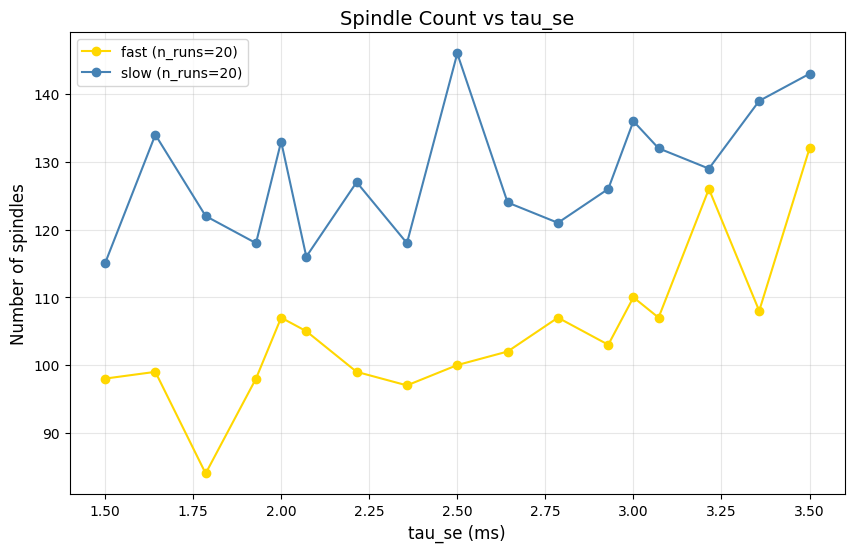

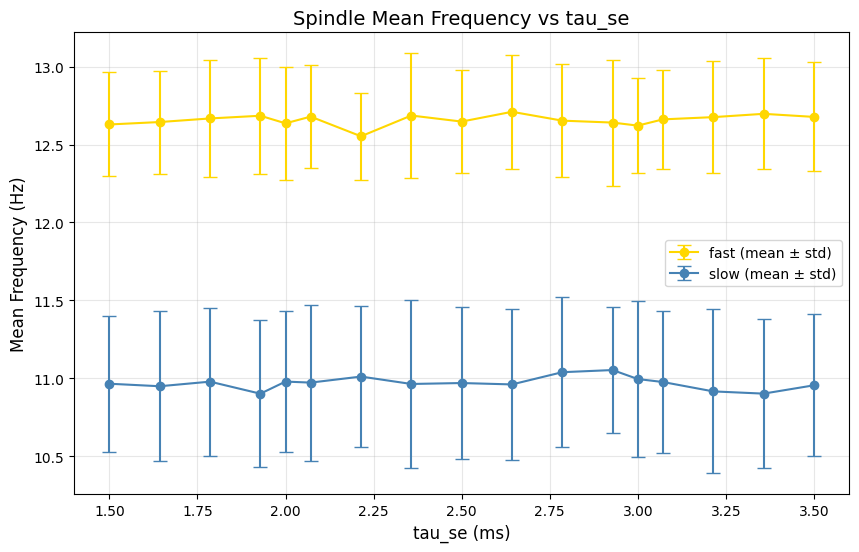

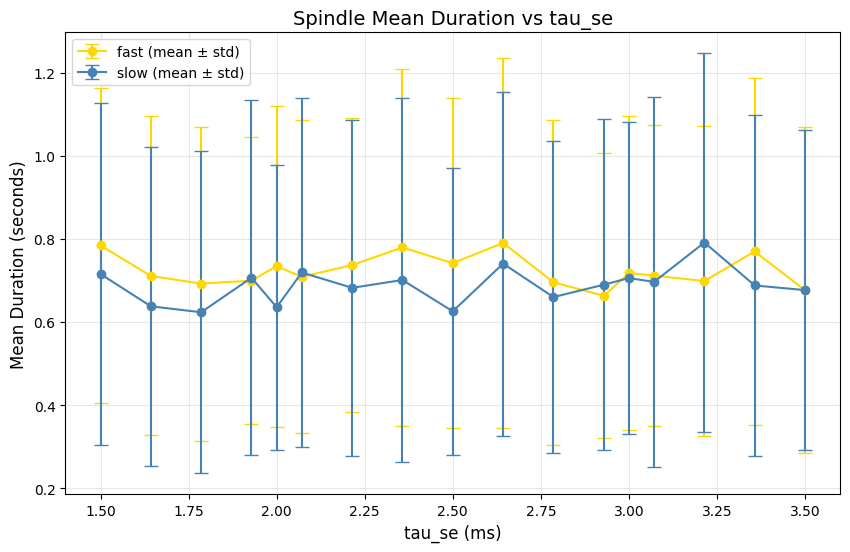

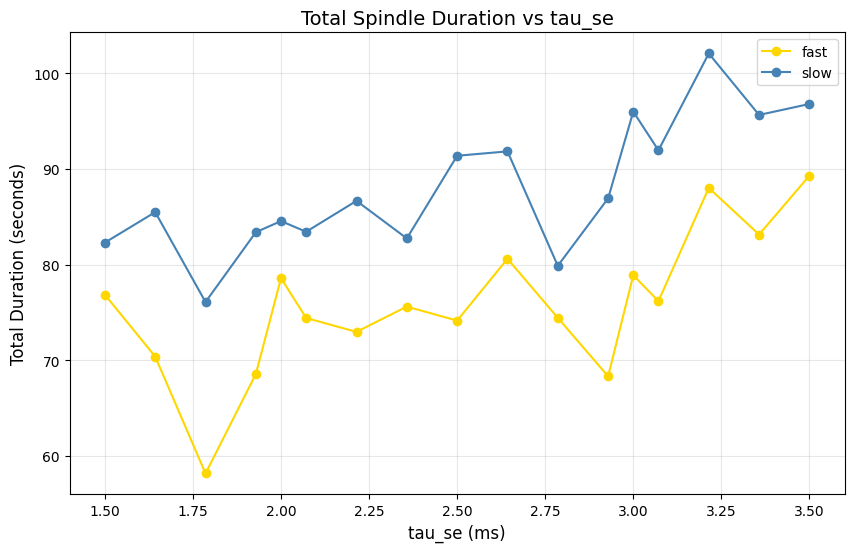

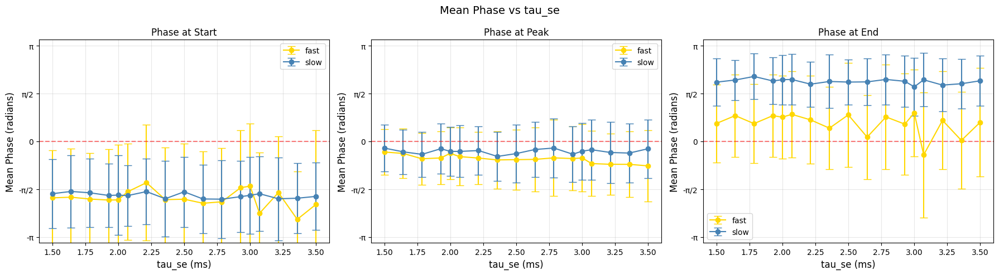

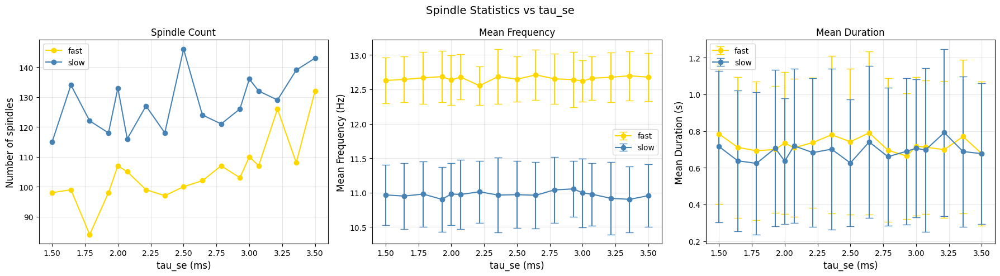


统计摘要

FAST 纺锤波:
  总数量: 1782
  tau_se=1.50: n= 98, mean_freq=12.63±0.33Hz, mean_dur=0.7843s, total_dur=76.8595s, mean_phase=-0.351 rad
  tau_se=1.64: n= 99, mean_freq=12.64±0.33Hz, mean_dur=0.7110s, total_dur=70.3886s, mean_phase=-0.397 rad
  tau_se=1.79: n= 84, mean_freq=12.67±0.38Hz, mean_dur=0.6925s, total_dur=58.1710s, mean_phase=-0.573 rad
  tau_se=1.93: n= 98, mean_freq=12.69±0.37Hz, mean_dur=0.6997s, total_dur=68.5681s, mean_phase=-0.545 rad
  tau_se=2.00: n=107, mean_freq=12.64±0.36Hz, mean_dur=0.7345s, total_dur=78.5953s, mean_phase=-0.395 rad
  tau_se=2.07: n=105, mean_freq=12.68±0.33Hz, mean_dur=0.7088s, total_dur=74.4227s, mean_phase=-0.502 rad
  tau_se=2.21: n= 99, mean_freq=12.55±0.28Hz, mean_dur=0.7371s, total_dur=72.9733s, mean_phase=-0.550 rad
  tau_se=2.36: n= 97, mean_freq=12.69±0.40Hz, mean_dur=0.7795s, total_dur=75.6140s, mean_phase=-0.611 rad
  tau_se=2.50: n=100, mean_freq=12.65±0.33Hz, mean_dur=0.7415s, total_dur=74.1519s, mean_phase=-0.602 rad
  tau_se=2.64: n=

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import circmean, circstd

# ========== 读取数据 ==========
df = pd.read_csv("data/analysis_data/spindles_tau_se_explore_valid_limited.csv")

# ========== 参数设置 ==========
phase_columns = ['phase_at_start', 'phase_at_peak', 'phase_at_end']
phase_labels = ['Start', 'Peak', 'End']
colors = {'fast': 'gold', 'slow': 'steelblue'}

# 获取唯一的 tau_se 值
tau_se_values = sorted(df['tau_se'].unique())
print(f"tau_se 值: {tau_se_values}")

# ========== 定义圆形统计函数 ==========
def circular_stats(phases):
    """返回平均相位、圆形标准差、样本数"""
    if hasattr(phases, 'dropna'):
        phase_clean = phases.dropna().values
    else:
        phase_clean = phases[~np.isnan(phases)]
    
    if len(phase_clean) == 0:
        return np.nan, np.nan, 0
    mean_phase = circmean(phase_clean, low=-np.pi, high=np.pi)
    std_phase = circstd(phase_clean, low=-np.pi, high=np.pi)
    return mean_phase, std_phase, len(phase_clean)

# ========== 图1：纺锤波数量随 tau_se 的变化 ==========
plt.figure(figsize=(10, 6))
for spindle_type in ['fast', 'slow']:
    subset = df[df['type'] == spindle_type]
    counts = subset.groupby('tau_se').size()
    tau_se_counts = subset.groupby('tau_se')['seed'].nunique()
    plt.plot(counts.index, counts.values, 'o-', color=colors[spindle_type], 
             label=f'{spindle_type} (n_runs={tau_se_counts.values[0] if len(tau_se_counts)>0 else 0})')
plt.xlabel('tau_se (ms)', fontsize=12)
plt.ylabel('Number of spindles', fontsize=12)
plt.title('Spindle Count vs tau_se', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
# plt.savefig("analysis_data/spindle_count_vs_tau_se.png", dpi=150)
plt.show()

# ========== 图2：纺锤波平均频率随 tau_se 的变化 ==========
plt.figure(figsize=(10, 6))
for spindle_type in ['fast', 'slow']:
    subset = df[df['type'] == spindle_type]
    mean_freq = subset.groupby('tau_se')['frequency'].mean()
    std_freq = subset.groupby('tau_se')['frequency'].std()
    plt.errorbar(mean_freq.index, mean_freq.values, yerr=std_freq.values,
                 fmt='o-', capsize=5, color=colors[spindle_type], 
                 label=f'{spindle_type} (mean ± std)')
plt.xlabel('tau_se (ms)', fontsize=12)
plt.ylabel('Mean Frequency (Hz)', fontsize=12)
plt.title('Spindle Mean Frequency vs tau_se', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
# plt.savefig("analysis_data/spindle_mean_frequency_vs_tau_se.png", dpi=150)
plt.show()

# ========== 图3：纺锤波平均时长随 tau_se 的变化 ==========
plt.figure(figsize=(10, 6))
for spindle_type in ['fast', 'slow']:
    subset = df[df['type'] == spindle_type]
    mean_duration = subset.groupby('tau_se')['duration'].mean()
    std_duration = subset.groupby('tau_se')['duration'].std()
    plt.errorbar(mean_duration.index, mean_duration.values, yerr=std_duration.values,
                 fmt='o-', capsize=5, color=colors[spindle_type], 
                 label=f'{spindle_type} (mean ± std)')
plt.xlabel('tau_se (ms)', fontsize=12)
plt.ylabel('Mean Duration (seconds)', fontsize=12)
plt.title('Spindle Mean Duration vs tau_se', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
# plt.savefig("analysis_data/spindle_mean_duration_vs_tau_se.png", dpi=150)
plt.show()

# ========== 图4：纺锤波总时长随 tau_se 的变化 ==========
plt.figure(figsize=(10, 6))
for spindle_type in ['fast', 'slow']:
    subset = df[df['type'] == spindle_type]
    total_duration = subset.groupby('tau_se')['duration'].sum()
    plt.plot(total_duration.index, total_duration.values, 'o-', color=colors[spindle_type], 
             label=f'{spindle_type}')
plt.xlabel('tau_se (ms)', fontsize=12)
plt.ylabel('Total Duration (seconds)', fontsize=12)
plt.title('Total Spindle Duration vs tau_se', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
# plt.savefig("analysis_data/spindle_total_duration_vs_tau_se.png", dpi=150)
plt.show()

# ========== 图5：平均相位随 tau_se 的变化 ==========
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (col, label) in enumerate(zip(phase_columns, phase_labels)):
    ax = axes[idx]
    for spindle_type in ['fast', 'slow']:
        subset = df[df['type'] == spindle_type]
        means = []
        stds = []
        tau_vals = []
        for tau in tau_se_values:
            phases = subset[subset['tau_se'] == tau][col].dropna().values
            if len(phases) > 0:
                mean_p, std_p, _ = circular_stats(phases)
                means.append(mean_p)
                stds.append(std_p)
                tau_vals.append(tau)
        if len(tau_vals) > 0:
            ax.errorbar(tau_vals, means, yerr=stds, fmt='o-', capsize=5,
                        color=colors[spindle_type], label=spindle_type)
    ax.set_xlabel('tau_se (ms)', fontsize=12)
    ax.set_ylabel('Mean Phase (radians)', fontsize=12)
    ax.set_title(f'Phase at {label}', fontsize=12)
    ax.set_ylim(-np.pi - 0.2, np.pi + 0.2)
    ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
    ax.set_yticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.3)
    ax.legend()
plt.suptitle('Mean Phase vs tau_se', fontsize=14)
plt.tight_layout()
# plt.savefig("analysis_data/mean_phase_vs_tau_se.png", dpi=150)
plt.show()

# ========== 图6：三张汇总图并排（数量、平均频率、平均时长）==========
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 子图1：数量
ax = axes[0]
for spindle_type in ['fast', 'slow']:
    subset = df[df['type'] == spindle_type]
    counts = subset.groupby('tau_se').size()
    ax.plot(counts.index, counts.values, 'o-', color=colors[spindle_type], label=spindle_type)
ax.set_xlabel('tau_se (ms)', fontsize=12)
ax.set_ylabel('Number of spindles', fontsize=12)
ax.set_title('Spindle Count', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# 子图2：平均频率
ax = axes[1]
for spindle_type in ['fast', 'slow']:
    subset = df[df['type'] == spindle_type]
    mean_freq = subset.groupby('tau_se')['frequency'].mean()
    std_freq = subset.groupby('tau_se')['frequency'].std()
    ax.errorbar(mean_freq.index, mean_freq.values, yerr=std_freq.values,
                fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
ax.set_xlabel('tau_se (ms)', fontsize=12)
ax.set_ylabel('Mean Frequency (Hz)', fontsize=12)
ax.set_title('Mean Frequency', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# 子图3：平均时长
ax = axes[2]
for spindle_type in ['fast', 'slow']:
    subset = df[df['type'] == spindle_type]
    mean_duration = subset.groupby('tau_se')['duration'].mean()
    std_duration = subset.groupby('tau_se')['duration'].std()
    ax.errorbar(mean_duration.index, mean_duration.values, yerr=std_duration.values,
                fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
ax.set_xlabel('tau_se (ms)', fontsize=12)
ax.set_ylabel('Mean Duration (s)', fontsize=12)
ax.set_title('Mean Duration', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('Spindle Statistics vs tau_se', fontsize=14)
plt.tight_layout()
# plt.savefig("analysis_data/spindle_stats_vs_tau_se_combined.png", dpi=150)
plt.show()

# ========== 打印统计摘要 ==========
print("\n" + "="*60)
print("统计摘要")
print("="*60)

for spindle_type in ['fast', 'slow']:
    subset = df[df['type'] == spindle_type]
    print(f"\n{spindle_type.upper()} 纺锤波:")
    print(f"  总数量: {len(subset)}")
    
    for tau_val in tau_se_values:
        sub = subset[subset['tau_se'] == tau_val]
        if len(sub) > 0:
            n_spindles = len(sub)
            mean_dur = sub['duration'].mean()
            total_dur = sub['duration'].sum()
            mean_freq = sub['frequency'].mean()
            std_freq = sub['frequency'].std()
            # 相位统计
            phases = sub['phase_at_peak'].dropna().values
            if len(phases) > 0:
                mean_phase, std_phase, _ = circular_stats(phases)
                print(f"  tau_se={tau_val:.2f}: n={n_spindles:3d}, mean_freq={mean_freq:.2f}±{std_freq:.2f}Hz, mean_dur={mean_dur:.4f}s, total_dur={total_dur:.4f}s, mean_phase={mean_phase:6.3f} rad")
            else:
                print(f"  tau_se={tau_val:.2f}: n={n_spindles:3d}, mean_freq={mean_freq:.2f}±{std_freq:.2f}Hz, mean_dur={mean_dur:.4f}s, total_dur={total_dur:.4f}s, no valid phase")

In [ ]:
import requests
ret = requests.get('https://api.day.app/TUiWwsBpShFTPWk8JWWLxW/program/thalamusfor20251128_11:10isdone')


In [ ]:
alhglsf

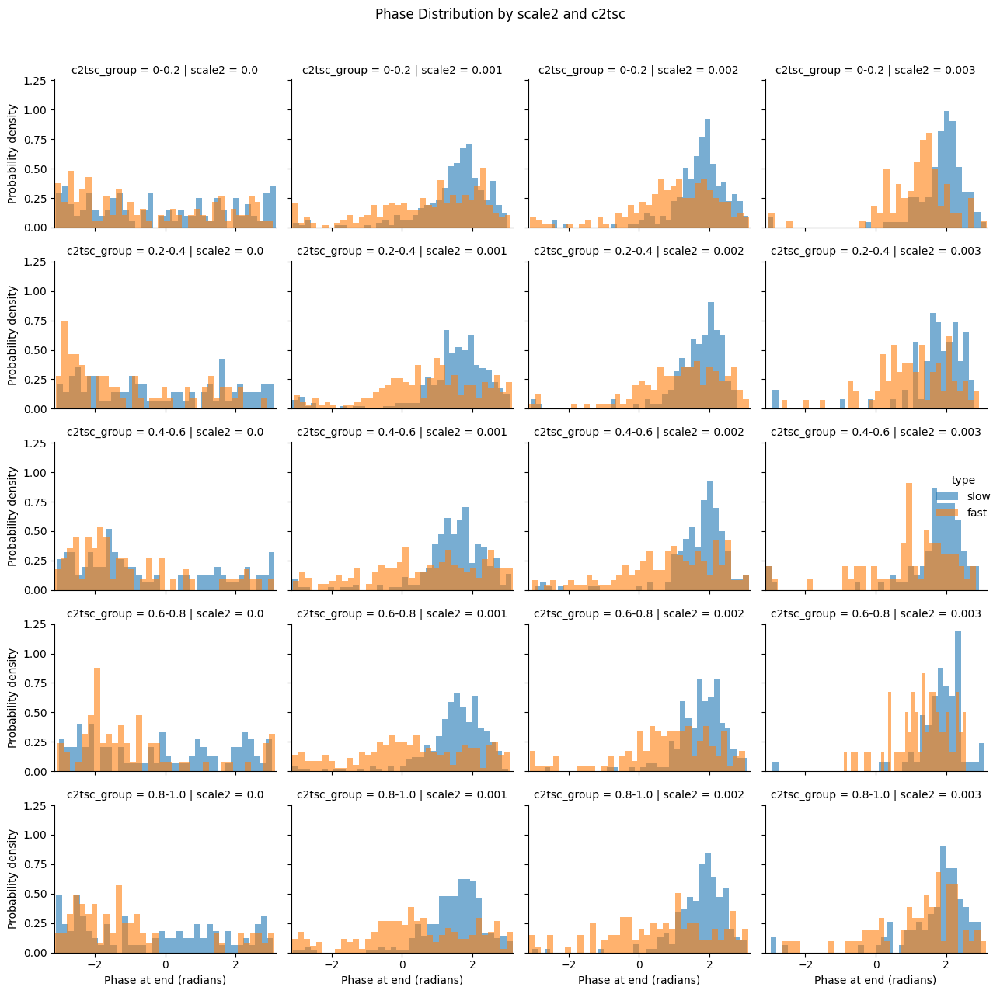

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt 
# 按 scale2 分面，画相位分布密度曲线
df = result_df
# 先对 c2tsc 离散化（比如分成 5 组），否则 20 个值子图太多
df['c2tsc_group'] = pd.cut(df['c2tsc'], bins=5, labels=['0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1.0'])

g = sns.FacetGrid(df, col='scale2', row='c2tsc_group', hue='type', 
                  height=2.5, aspect=1.2, sharex=True, sharey=True)
g.map(plt.hist, 'phase_at_end', bins=36, density=True, alpha=0.6)
g.add_legend()
g.set_axis_labels('Phase at end (radians)', 'Probability density')
g.set(xlim=(-np.pi, np.pi))
plt.suptitle('Phase Distribution by scale2 and c2tsc', y=1.02)
plt.tight_layout()
plt.savefig('analysis_data/phase_distribution_grid.png', dpi=150)
plt.show()

In [ ]:
import requests
ret = requests.get('https://api.day.app/TUiWwsBpShFTPWk8JWWLxW/program/thalamusfor20251128_11:10isdone')


In [ ]:
sgahkgl

NameError: name 'sgahkgl' is not defined

In [ ]:
# for test

#t, Q_t, Q_r, V_t, V_r, a_chunk, b_chunk, c_chunk, u_chunk, ar_chunk, br_chunk, cr_chunk, dr_chunk, ur_chunk = rm.runModels(manual_params=params)
#t, Q_t, Q_r, V_t, V_r, Q_e, Q_i, V_e, V_i, c, V_e2, V_i2, c2 = rm.runModels(manual_params=params)
#t, Q_t, Q_r, V_t, V_r, u_chunk, ur_chunk = rm.runModels(manual_params=params)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import circmean, circstd
import os

# ========== 设置 ==========
plt.rcParams['font.size'] = 10
os.makedirs("analysis_data", exist_ok=True)

# ========== 读取数据 ==========
df = pd.read_csv("data/analysis_data/spindles_all.csv")
print(f"总数据量: {len(df)} 行")
print(f"参数范围: {df['param'].min():.4f} ~ {df['param'].max():.4f}")
print(f"纺锤波类型: {df['type'].unique()}")
print(f"列名: {df.columns.tolist()}")
print("\n前几行:")
print(df.head())

# ========== 定义圆形统计函数 ==========
def circular_stats(phase_series):
    """返回平均相位和圆形标准差"""
    phase_clean = phase_series.dropna().values
    if len(phase_clean) == 0:
        return np.nan, np.nan
    mean_phase = circmean(phase_clean, low= - np.pi, high=np.pi)
    std_phase = circstd(phase_clean, low= - np.pi, high=np.pi)
    return mean_phase, std_phase

# ========== 1. 按参数和类型分组统计 ==========
stats = []
for spindle_type in ['fast', 'slow']:
    for param in sorted(df['param'].unique()):
        subset = df[(df['type'] == spindle_type) & (df['param'] == param)]
        
        # phase_at_start
        mean_start, std_start = circular_stats(subset['phase_at_start'])
        n_start = subset['phase_at_start'].dropna().shape[0]
        
        # phase_at_peak
        mean_peak, std_peak = circular_stats(subset['phase_at_peak'])
        n_peak = subset['phase_at_peak'].dropna().shape[0]
        
        stats.append({
            'type': spindle_type,
            'param': param,
            'n_spindles': len(subset),
            'n_start': n_start,
            'n_peak': n_peak,
            'mean_phase_start': mean_start,
            'circ_std_start': std_start,
            'mean_phase_peak': mean_peak,
            'circ_std_peak': std_peak,
        })

stats_df = pd.DataFrame(stats)
stats_df.to_csv("analysis_data/phase_statistics.csv", index=False)
print("\n统计结果:")
print(stats_df)

# ========== 2. 画平均相位随参数变化的折线图 ==========
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, phase_col in enumerate(['mean_phase_start', 'mean_phase_peak']):
    ax = axes[idx]
    for spindle_type in ['fast', 'slow']:
        subset = stats_df[stats_df['type'] == spindle_type]
        params = subset['param'].values
        mean_phases = subset[phase_col].values
        circ_stds = subset['circ_std_start' if 'start' in phase_col else 'circ_std_peak'].values
        
        # 过滤 NaN
        valid = ~np.isnan(mean_phases)
        params_valid = params[valid]
        mean_valid = mean_phases[valid]
        std_valid = circ_stds[valid]
        
        if len(params_valid) > 0:
            ax.errorbar(params_valid, mean_valid, yerr=std_valid,
                       fmt='o-', capsize=5, capthick=2, linewidth=2,
                       markersize=8, label=spindle_type)
    
    ax.set_xlabel("scale2", fontsize=12)
    ax.set_ylabel("Mean phase (radians)", fontsize=12)
    ax.set_title(f"{phase_col.replace('mean_phase_', '')}", fontsize=12)
    ax.set_ylim(-np.pi, np.pi)
    ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
    ax.set_yticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.suptitle("Mean Phase vs scale2", fontsize=14)
plt.tight_layout()
plt.savefig("analysis_data/phase_vs_scale2.png", dpi=150)
plt.show()

总数据量: 27924 行


KeyError: 'param'

In [ ]:
import requests
ret = requests.get('https://api.day.app/TUiWwsBpShFTPWk8JWWLxW/program/thalamusfor20251128_11:10isdone')
